**Assessment#5: Ensemble Methods and Advanced Classifications**
-
* **Name:** Enrico Miguel Veloso
* **Section:** 2DSA-2
* **Course:** DSA#4155 - Artificial Intelligence
* **Date:** 3/5/2026
* **Department:** College of Science
* **Institution:** University of Santo Tomas
----
* **Implementation of models and concepts:** Bagging, Random Forest, and Ensemble Learning
* **Dataset:** Adult Income (Census 1994)
* **Dataset Description:** The Adult Income dataset contains demographic and employment information for 32,561 individuals from the 1994 U.S. Census. In this assessment, you will implement ensemble learning methods (Bagging and Random Forest) and compare them with traditional approaches and individual decision trees. You will analyze how ensemble methods reduce variance, improve prediction stability, and enhance model performance through aggregation of multiple learners.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import statsmodels.formula.api as smf
import random
import time
import warnings
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
warnings.filterwarnings('ignore')

#Set plotting style:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#Set seed:
random.seed(16)

**1. Data Preparation and Quick EDA**
-

In [2]:
#Load the dataset:
df = fetch_openml('adult', version = 2, as_frame = True)
df = df.frame
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
#Check dataframe shape:
df_shape = df.shape

In [4]:
print("Total number of rows:", df_shape[0])
print("Total number of columns:", df_shape[1])

Total number of rows: 48842
Total number of columns: 15


In [5]:
#Dataset descriptive statistics:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
#Check for null values:
num_null_col = df.isnull().sum()
num_null_row = df.isnull().any(axis=1).sum()
num_not_null_row = df.notnull().all(axis=1).sum()

In [7]:
print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 3620


In [8]:
#Handling missing values:
df_clean = df.dropna()
num_null_col = df_clean.isnull().sum()
num_null_row = df_clean.isnull().any(axis=1).sum()
num_not_null_row = df_clean.notnull().all(axis=1).sum()
total_rows = df.shape[0]
remaining_rows = df_clean.shape[0]
data_loss_percent = ((total_rows - remaining_rows) / total_rows) * 100

In [9]:
print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)
print("Data loss after dropping all rows with null values:", f"{data_loss_percent:.2f}","%")

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 0
Data loss after dropping all rows with null values: 7.41 %


In [10]:
#Create target variable:
df_clean['high_income'] = (df_clean['class'] == '>50K').astype(int)
df_clean = df_clean.drop('class', axis = 1)
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,high_income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


In [11]:
#Target variable distribution in counts and percentages:
counts = df_clean['high_income'].value_counts().sort_index()
percentages = df_clean['high_income'].value_counts(normalize=True).sort_index() * 100

In [12]:
print("=" * 40)
print("Counts:", counts)
print("=" * 40)
print("Percentages:", percentages)

Counts: high_income
0    34014
1    11208
Name: count, dtype: int64
Percentages: high_income
0    75.215603
1    24.784397
Name: proportion, dtype: float64


In [13]:
#Group all columns that are categorical:
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = " | ".join(categorical_cols)

In [14]:
print("Categorical columns:", categorical_cols)

Categorical columns: workclass | education | marital-status | occupation | relationship | race | sex | native-country


In [15]:
#Convert categorical to dummy variables:
dum_WC = pd.get_dummies(df_clean['workclass'], prefix = "WC", drop_first = True).astype(int)
dum_EDUC = pd.get_dummies(df_clean['education'], prefix = "EDUC", drop_first = True).astype(int)
dum_MS = pd.get_dummies(df_clean['marital-status'], prefix = "MS", drop_first = True).astype(int)
dum_OCC = pd.get_dummies(df_clean['occupation'], prefix = "OCC", drop_first = True).astype(int)
dum_REL = pd.get_dummies(df_clean['relationship'], prefix = "REL", drop_first = True).astype(int)
dum_RCE = pd.get_dummies(df_clean['race'], prefix = "RCE", drop_first = True).astype(int)
dum_SX = pd.get_dummies(df_clean['sex'], prefix = "SX", drop_first = True).astype(int)
dum_NC = pd.get_dummies(df_clean['native-country'], prefix = "NC", drop_first = True).astype(int)
df_clean = pd.concat([df_clean, dum_WC, dum_EDUC, dum_MS, dum_OCC, dum_REL, dum_RCE, dum_SX, dum_NC], axis = 1)
df_clean = df_clean.dropna()
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,NC_Portugal,NC_Puerto-Rico,NC_Scotland,NC_South,NC_Taiwan,NC_Thailand,NC_Trinadad&Tobago,NC_United-States,NC_Vietnam,NC_Yugoslavia
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,...,0,0,0,0,0,0,0,1,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,...,0,0,0,0,0,0,0,1,0,0
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,...,0,0,0,0,0,0,0,1,0,0


In [16]:
#Check if there are null values after creation of dummy variables:
print("Check if there are null values after creation of dummy variables")
print("=" * 64)
print(df_clean.isnull().sum())

Check if there are null values after creation of dummy variables
age                   0
workclass             0
fnlwgt                0
education             0
education-num         0
                     ..
NC_Thailand           0
NC_Trinadad&Tobago    0
NC_United-States      0
NC_Vietnam            0
NC_Yugoslavia         0
Length: 106, dtype: int64


In [17]:
#Drop non-numerical features or columns:
df_clean = df_clean.select_dtypes(include = ['number'])
numerical_cols = " | ".join(df_clean.columns.tolist())
num_cols = len(df_clean.columns.tolist())

In [18]:
print("Total number of columns or features:", num_cols)
print("=" * 60)
print(numerical_cols)

Total number of columns or features: 98
age | fnlwgt | education-num | capital-gain | capital-loss | hours-per-week | high_income | WC_Local-gov | WC_Never-worked | WC_Private | WC_Self-emp-inc | WC_Self-emp-not-inc | WC_State-gov | WC_Without-pay | EDUC_11th | EDUC_12th | EDUC_1st-4th | EDUC_5th-6th | EDUC_7th-8th | EDUC_9th | EDUC_Assoc-acdm | EDUC_Assoc-voc | EDUC_Bachelors | EDUC_Doctorate | EDUC_HS-grad | EDUC_Masters | EDUC_Preschool | EDUC_Prof-school | EDUC_Some-college | MS_Married-AF-spouse | MS_Married-civ-spouse | MS_Married-spouse-absent | MS_Never-married | MS_Separated | MS_Widowed | OCC_Armed-Forces | OCC_Craft-repair | OCC_Exec-managerial | OCC_Farming-fishing | OCC_Handlers-cleaners | OCC_Machine-op-inspct | OCC_Other-service | OCC_Priv-house-serv | OCC_Prof-specialty | OCC_Protective-serv | OCC_Sales | OCC_Tech-support | OCC_Transport-moving | REL_Not-in-family | REL_Other-relative | REL_Own-child | REL_Unmarried | REL_Wife | RCE_Asian-Pac-Islander | RCE_Black | RCE_

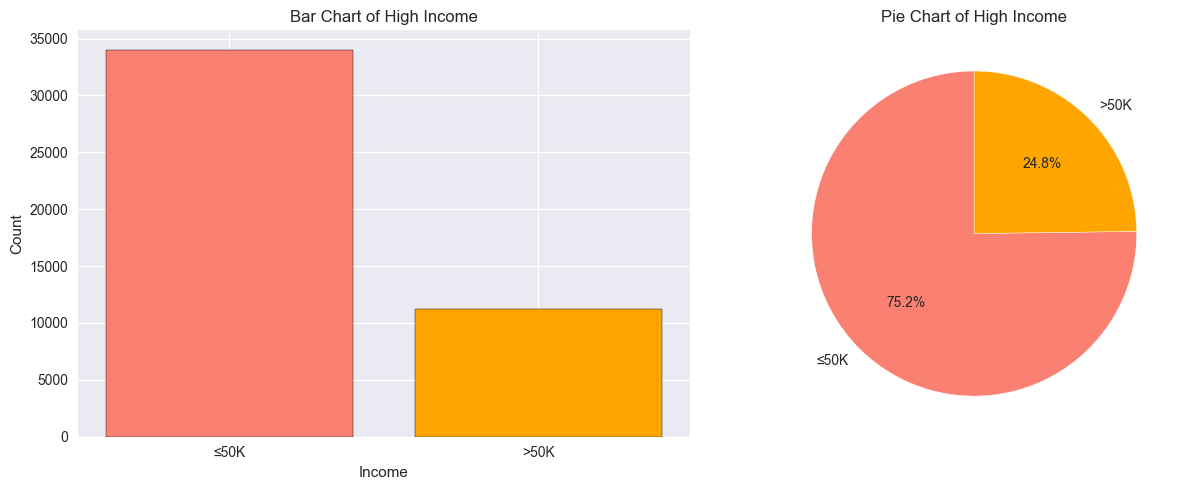

In [19]:
#Visualizations showing the distribution of the target variable:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Bar chart (counts):
counts = df_clean['high_income'].value_counts().sort_index()
axes[0].bar(['≤50K', '>50K'], counts, color=['salmon', 'orange'], edgecolor='black')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')
axes[0].set_title('Bar Chart of High Income')

#Pie chart (percentages):
df_clean['high_income'].value_counts().plot.pie(autopct='%1.1f%%', labels=['≤50K', '>50K'], colors=['salmon', 'orange'], ax=axes[1], startangle=90)
axes[1].set_title('Pie Chart of High Income')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

* This is the distribution of values from the target variable "high_income".
* The majority of users are below or equal to the 50k marked which label's them as low incoming individuals.
* We used piechart and bar graph to better visualize the difference in number.
* There is a class imbalance in terms of individuals who have high and low income.

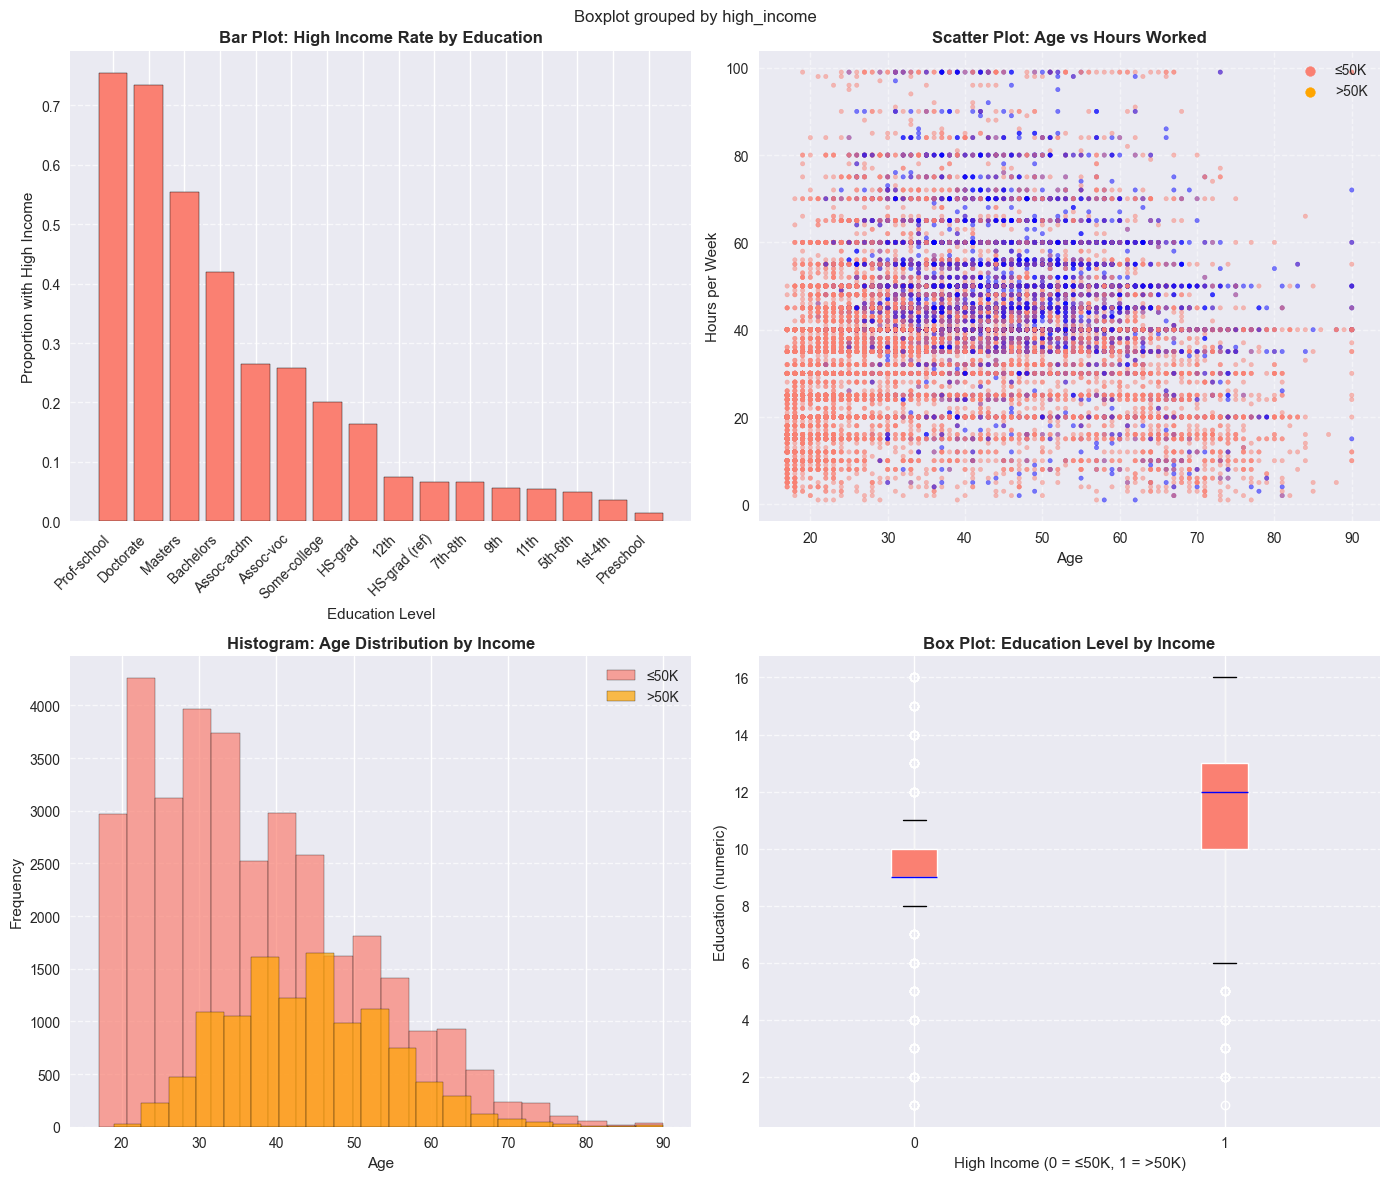

In [20]:
#Generate at least 3 informative plots exploring relationships between features and target:

#Prepare data for education bar plot (using dummy columns from your encoding):
educ_dummies = [col for col in df_clean.columns if col.startswith('EDUC_')]
educ_means = []
for col in educ_dummies:
    mean_val = df_clean.loc[df_clean[col] == 1, 'high_income'].mean()
    cat_name = col.replace('EDUC_', '')
    educ_means.append((cat_name, mean_val))

#Reference category (all dummies = 0) – label it appropriately:
ref_mask = (df_clean[educ_dummies] == 0).all(axis=1)
ref_mean = df_clean.loc[ref_mask, 'high_income'].mean()
educ_means.append(('HS-grad (ref)', ref_mean))
educ_df = pd.DataFrame(educ_means, columns=['Education', 'Proportion_High_Income'])
educ_df = educ_df.sort_values('Proportion_High_Income', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Relationships Between Features and Income', fontsize=16, fontweight='bold')

#Bar plot: Education vs High Income Rate;
ax = axes[0, 0]
bars = ax.bar(educ_df['Education'], educ_df['Proportion_High_Income'], color='salmon', edgecolor='black')
ax.set_xlabel('Education Level')
ax.set_ylabel('Proportion with High Income')
ax.set_title('Bar Plot: High Income Rate by Education', fontweight='bold')
ax.set_xticklabels(educ_df['Education'], rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

#Scatter plot: Age vs Hours per Week:
ax = axes[0, 1]
colors = df_clean['high_income'].map({0: 'salmon', 1: 'blue'})
ax.scatter(df_clean['age'], df_clean['hours-per-week'], c=colors, alpha=0.5, s=10)
ax.set_xlabel('Age')
ax.set_ylabel('Hours per Week')
ax.set_title('Scatter Plot: Age vs Hours Worked', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.scatter([], [], color='salmon', label='≤50K')
ax.scatter([], [], color='orange', label='>50K')
ax.legend()

#Histogram: Age distribution by income group:
ax = axes[1, 0]
df_clean[df_clean['high_income'] == 0]['age'].hist(ax=ax, bins=20, alpha=0.7, label='≤50K', color='salmon', edgecolor='black')
df_clean[df_clean['high_income'] == 1]['age'].hist(ax=ax, bins=20, alpha=0.7, label='>50K', color='orange', edgecolor='black')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Histogram: Age Distribution by Income', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

#Box plot: Education-num by income group:
ax = axes[1, 1]
df_clean.boxplot(column='education-num', by='high_income', ax=ax, patch_artist=True, boxprops=dict(facecolor='salmon'), medianprops=dict(color='blue'))
ax.set_title('Box Plot: Education Level by Income', fontweight='bold')
ax.set_xlabel('High Income (0 = ≤50K, 1 = >50K)')
ax.set_ylabel('Education (numeric)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

* Created 4 visualizations about the following:
  * **Bar Plot:** which depicts high income rate by education.
  * **Scatter Plot:** depicts age vs hour worked.
  * **Histogram:** shows the distribution age by income.
  * **Box Plot:** which emphasizes education level by income. 

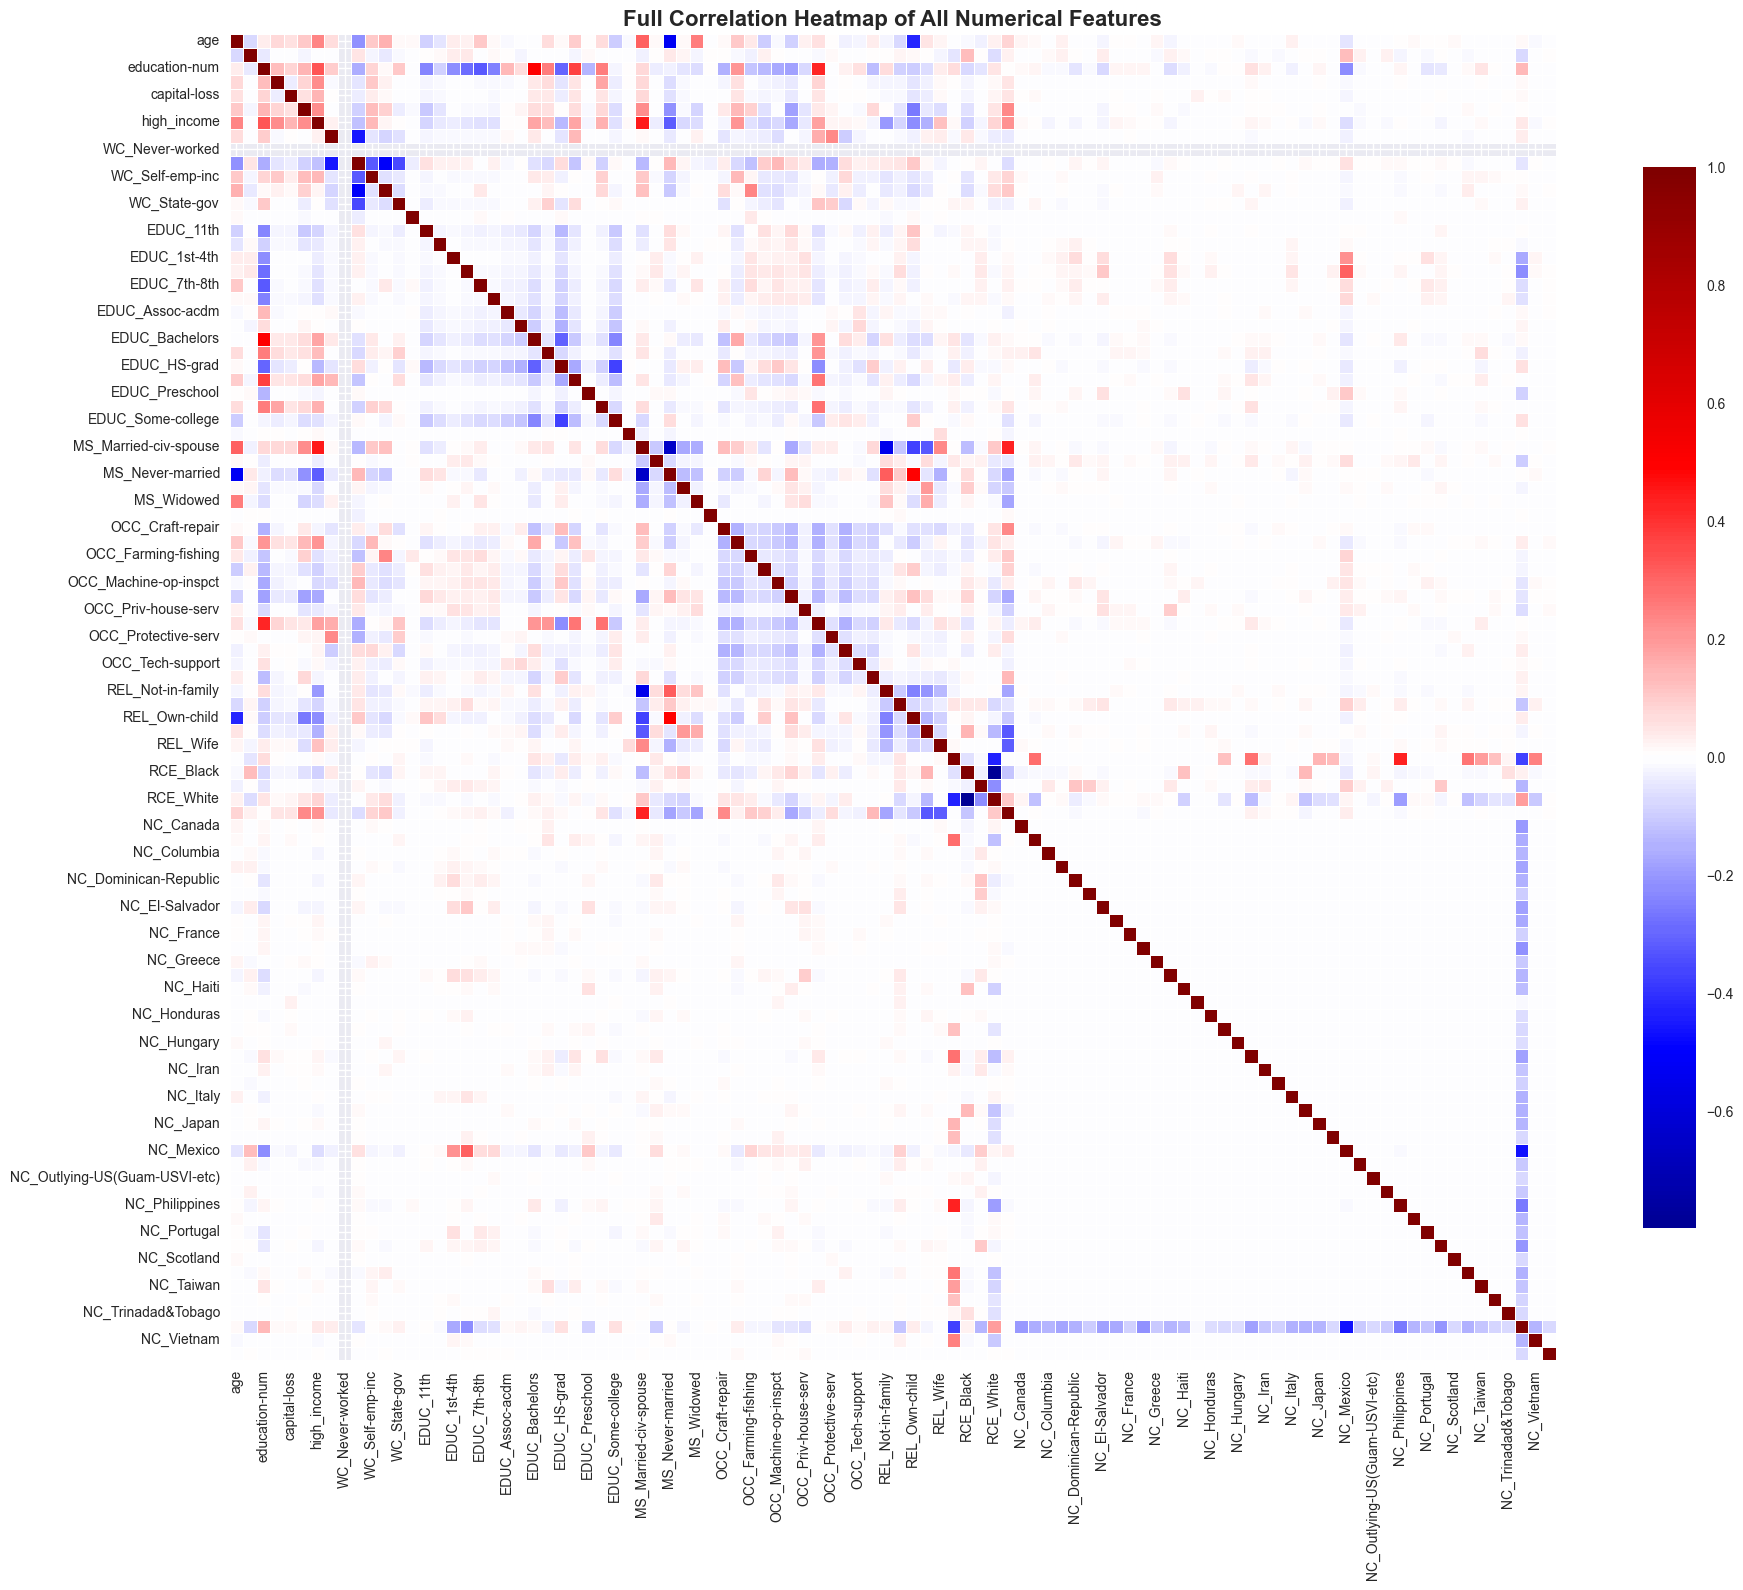

In [21]:
#Correlation heatmap for numerical features:
plt.figure(figsize=(20, 16))
corr_full = df_clean.corr()
sns.heatmap(corr_full, annot=False, cmap='seismic', center=0,square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Full Correlation Heatmap of All Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

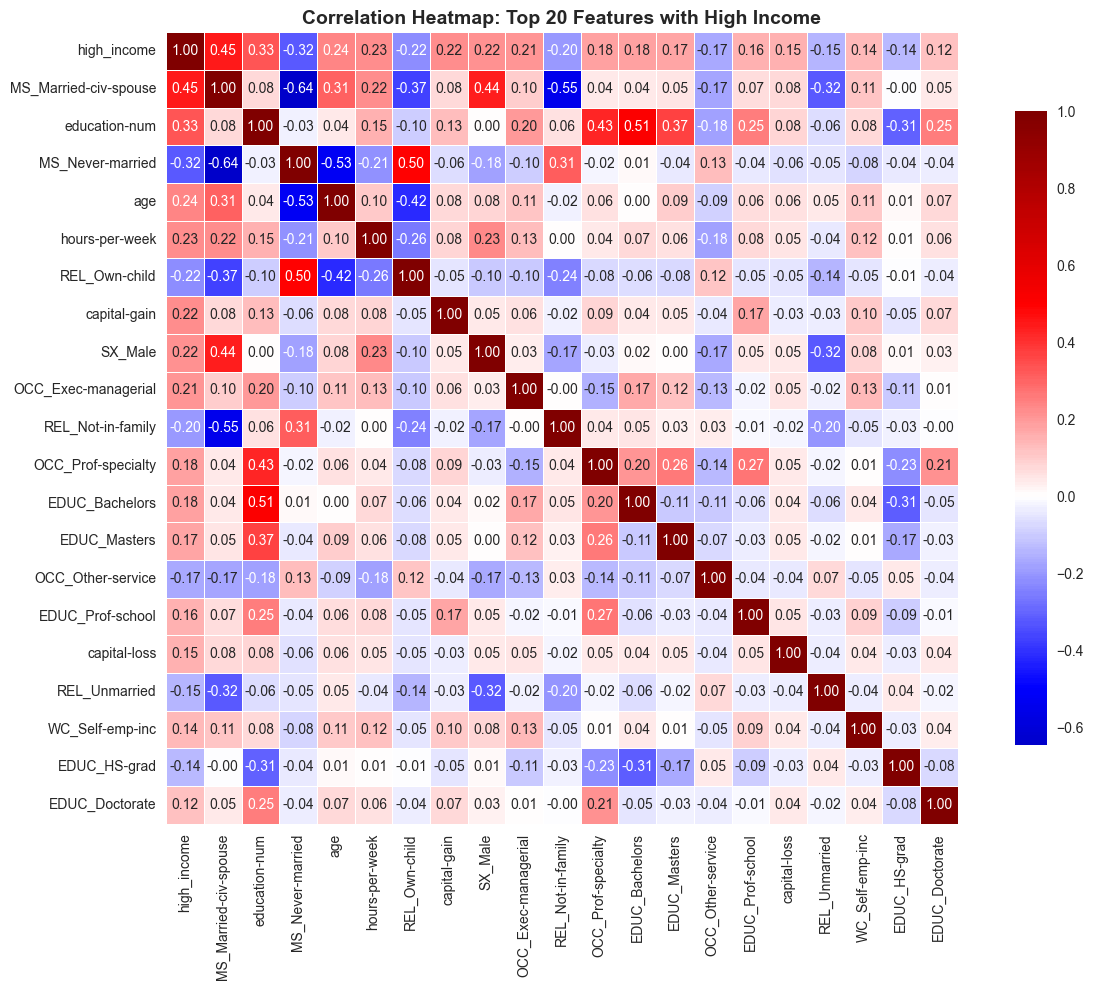

In [22]:
#Focused heatmap: top 20 features most correlated with high_income:
corr_target = df_clean.corr()['high_income'].abs().sort_values(ascending=False)
top_features = corr_target.head(21).index
plt.figure(figsize=(13, 10))
sns.heatmap(df_clean[top_features].corr(), annot=True, fmt='.2f', cmap='seismic', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 20 Features with High Income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**2. Train-Test Split and Feature Selection**
-

In [23]:
#Prepare your feature (X) and target variable (y) for Random Forest application of features selection:
X = df_clean.drop('high_income', axis = 1)
y = df_clean['high_income']

In [24]:
#Split dataframe to test and train sets for Random Forest application:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [25]:
#Display the shapes of training and testing sets:
print("Training set shape:")
print("=" * 40)
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print("=" * 40)
print("Testing set shape:")
print("=" * 40)
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Training set shape:
X_train: (36177, 97)
y_train: (36177,)
Testing set shape:
X_test: (9045, 97)
y_test: (9045,)


In [26]:
#Train a Random Forest classifier on the training set using all features:
rf_selector = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_selector.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
#Extract feature importance scores:
importances = rf_selector.feature_importances_
feature_names = X_train.columns

In [28]:
#Create a DataFrame for feature importance:
feat_imp_df = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

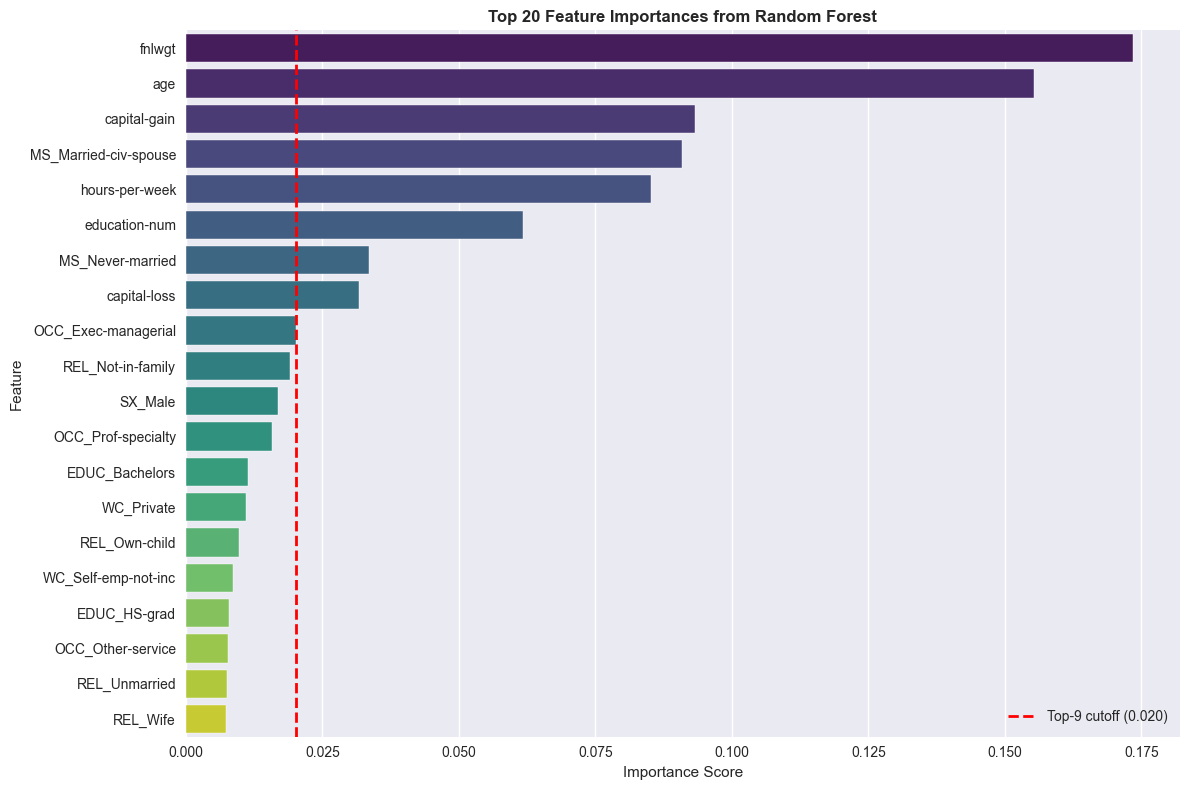

In [29]:
#Create a visualization (bar plot) showing feature importance scores:

#Show top 20 for clarity (you can adjust or show all by removing head(20)):
plt.figure(figsize=(12, 8))
top_n = 20
top_features = feat_imp_df.head(top_n)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
k = 9
if len(top_features) >= k:
    threshold_value = top_features.iloc[k-1]['Importance']
    plt.axvline(x=threshold_value, color='red', linestyle='--', linewidth=2,
                label=f'Top-{k} cutoff ({threshold_value:.3f})')
    plt.legend()
plt.title(f'Top {top_n} Feature Importances from Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [30]:
#Select the top 12 most important features:
top_12_features = feat_imp_df.head(12)['Feature'].tolist()

In [31]:
print("Top 12 selected features:")
print("=" * 60)
print(" | ".join(top_12_features))

Top 12 selected features:
fnlwgt | age | capital-gain | MS_Married-civ-spouse | hours-per-week | education-num | MS_Never-married | capital-loss | OCC_Exec-managerial | REL_Not-in-family | SX_Male | OCC_Prof-specialty


In [32]:
#Create a table showing: Feature name, Importance score, Selected (Yes/No):
feat_imp_df['Selected'] = feat_imp_df['Feature'].isin(top_12_features).map({True: 'Yes', False: 'No'})

In [33]:
print("Top 12 features with selection status:")
print("=" * 55)
print(feat_imp_df.head(12).to_string(index=False))

Top 12 features with selection status:
              Feature  Importance Selected
               fnlwgt    0.173390      Yes
                  age    0.155251      Yes
         capital-gain    0.093277      Yes
MS_Married-civ-spouse    0.090865      Yes
       hours-per-week    0.085103      Yes
        education-num    0.061726      Yes
     MS_Never-married    0.033485      Yes
         capital-loss    0.031683      Yes
  OCC_Exec-managerial    0.020269      Yes
    REL_Not-in-family    0.019149      Yes
              SX_Male    0.016796      Yes
   OCC_Prof-specialty    0.015760      Yes


In [34]:
#Prepare the reduced feature set (X_train_selected, X_test_selected) for model training:
X_train_selected = X_train[top_12_features]
X_test_selected = X_test[top_12_features]

In [35]:
print(f"Reduced feature set shape:")
print("=" * 40)
print(f"X_train_selected: {X_train_selected.shape}")
print(f"X_test_selected: {X_test_selected.shape}")

Reduced feature set shape:
X_train_selected: (36177, 12)
X_test_selected: (9045, 12)


**Brief Interpretation: Why might Random Forest feature selection is more robust compared to a single Decision Tree?**
* **Reduces variance** – A single tree is highly sensitive to data changes; Random Forest averages many trees for stable results.
* **Averages multiple models** – Aggregating importance scores across trees dilutes individual tree biases.
* **Random feature selection** – Considers random feature subsets at each split, preventing dominance by a few features.
* **Uses out-of-bag (OOB) samples** – Provides unbiased internal validation without a separate test set.
* **Robust to outliers and noise** – Ensemble approach dampens the impact of noisy data points.

**3. Six-Model Training and Implementation**
-

In [36]:
#Add constant to feature set:
X_train_sm = sm.add_constant(X_train_selected)
X_test_sm = sm.add_constant(X_test_selected)

**1.) Logistic Regression:**

In [37]:
#LRM based from the selected features derived from the Random Forest feature selection:
lrm = sm.Logit(y_train, X_train_sm).fit()

Optimization terminated successfully.
         Current function value: 0.336591
         Iterations 8


In [38]:
#Display all coefficients with feature names in a table:
logit_coef = lrm.params[1:]
coef_logit = pd.DataFrame({'Feature': X_train_selected.columns, 'Logistic β': logit_coef.values})

In [39]:
print("Logistic Regression Coefficients:")
print("=" * 60)
print(coef_logit.to_string(index=False))

Logistic Regression Coefficients:
              Feature    Logistic β
               fnlwgt  8.077517e-07
                  age  2.205850e-02
         capital-gain  3.092152e-04
MS_Married-civ-spouse  2.553637e+00
       hours-per-week  2.636031e-02
        education-num  3.063924e-01
     MS_Never-married -5.569250e-01
         capital-loss  6.491369e-04
  OCC_Exec-managerial  8.279366e-01
    REL_Not-in-family  5.927883e-01
              SX_Male  1.648719e-01
   OCC_Prof-specialty  5.210492e-01


In [40]:
#Training accuracy of Logistic Regression:
y_train_pred_prob_lrm = lrm.predict(X_train_sm)
y_train_pred_lrm = (y_train_pred_prob_lrm > 0.5).astype(int)
lrm_train_acc = accuracy_score(y_train, y_train_pred_lrm)

In [41]:
print("=" * 60)
print(f"Logistic Regression Training Accuracy: {lrm_train_acc:.4f}")

Logistic Regression Training Accuracy: 0.8424


**2.) Linear Probability Model (LPM):**

In [42]:
#LPM based from the selected features derived from the Random Forest feature selection:
lpm = sm.OLS(y_train, X_train_sm).fit()

In [43]:
#Display all coefficients with feature names in a table:
lpm_coef = lpm.params[1:]
coef_lpm = pd.DataFrame({'Feature': X_train_selected.columns, 'LPM β': lpm_coef.values})

In [44]:
print("Linear Probability Model Coefficients:")
print("=" * 60)
print(coef_lpm.to_string(index=False))

Linear Probability Model Coefficients:
              Feature         LPM β
               fnlwgt  9.934016e-08
                  age  2.676259e-03
         capital-gain  8.232820e-06
MS_Married-civ-spouse  2.857840e-01
       hours-per-week  2.529466e-03
        education-num  3.663915e-02
     MS_Never-married -4.801303e-03
         capital-loss  9.459204e-05
  OCC_Exec-managerial  1.451946e-01
    REL_Not-in-family -1.784106e-02
              SX_Male  3.041465e-02
   OCC_Prof-specialty  9.464867e-02


In [45]:
#Training accuracy of Linear Probability Model:
y_train_pred_prob_lpm = lpm.predict(X_train_sm)
y_train_pred_lpm = (y_train_pred_prob_lpm > 0.5).astype(int)
lpm_train_acc = accuracy_score(y_train, y_train_pred_lpm)

In [46]:
print("=" * 60)
print(f"Linear Probability Model Training Accuracy: {lpm_train_acc:.4f}")

Linear Probability Model Training Accuracy: 0.8303


**3.) K-Nearest Neighbors (K=9):**

In [47]:
#K-Nearest Neighbors (K=9) - using sklearn (requires scaling):
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)

knn = KNeighborsClassifier(n_neighbors = 9)
knn.fit(X_train_selected_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [48]:
#Training accuracy of KNN: 
y_train_pred_knn = knn.predict(X_train_selected_scaled) 
knn_train_acc = accuracy_score(y_train, y_train_pred_knn)

In [49]:
print("=" * 60)
print(f"K-Nearest Neighbors (K=9) Training Accuracy: {knn_train_acc:.4f}")

K-Nearest Neighbors (K=9) Training Accuracy: 0.8641


**4.) Single Decision Tree:**

In [50]:
#Single Decision Tree - using sklearn (default parameters):
dt = DecisionTreeClassifier(max_depth = 10, random_state = 42)
dt.fit(X_train_selected, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [51]:
#Training accuracy of a Single Decision Tree and node count: 
dt_train_acc = dt.score(X_train_selected, y_train)
dt_nodes = dt.tree_.node_count

In [52]:
print("=" * 60)
print(f"Single Decision Tree Training Accuracy: {dt_train_acc:.4f}")

Single Decision Tree Training Accuracy: 0.8650


In [53]:
#Extract feature importance scores from Single Decision Tree:
importances_dt = dt.feature_importances_
feature_names_dt = X_train_selected.columns

In [54]:
#Create a DataFrame for feature importance from Single Decision Tree:
feat_imp_df_dt = pd.DataFrame({'Feature': feature_names_dt,'Importance': importances_dt}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [55]:
print("Top 12 features from Single Decision Tree:")
print("=" * 45)
print(feat_imp_df_dt.head(12).to_string(index=False))

Top 12 features from Single Decision Tree:
              Feature  Importance
MS_Married-civ-spouse    0.393826
        education-num    0.219615
         capital-gain    0.188989
         capital-loss    0.068767
                  age    0.051091
       hours-per-week    0.029529
               fnlwgt    0.021215
  OCC_Exec-managerial    0.015125
              SX_Male    0.005886
   OCC_Prof-specialty    0.005015
     MS_Never-married    0.000477
    REL_Not-in-family    0.000465


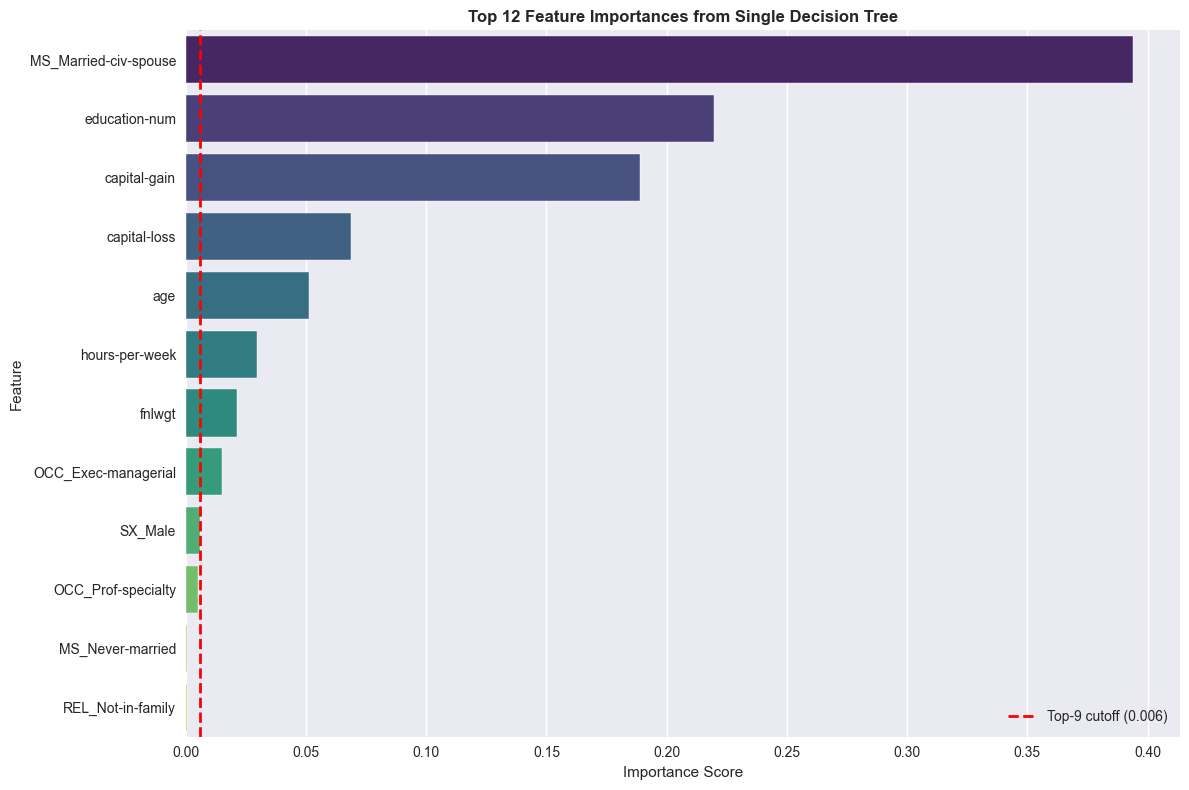

In [56]:
#Create a visualization (bar plot) showing feature importance scores from Single Decision Tree:

#Show all 12 for clarity (you can adjust or show all by removing head(12)):
plt.figure(figsize=(12, 8))
top_n = 12
top_features = feat_imp_df_dt.head(top_n)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
k = 9
if len(top_features) >= k:
    threshold_value = top_features.iloc[k-1]['Importance']
    plt.axvline(x=threshold_value, color='red', linestyle='--', linewidth=2,
                label=f'Top-{k} cutoff ({threshold_value:.3f})')
    plt.legend()
plt.title(f'Top {top_n} Feature Importances from Single Decision Tree', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**5.) Bagging Classifier:**

In [57]:
#Bagging Classifier - using sklearn:
bggg = BaggingClassifier(estimator = DecisionTreeClassifier(random_state = 42), n_estimators = 100, random_state = 42)
bggg.fit(X_train_selected, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [58]:
#Bagging Classifier training accuracy (100 decision trees):
bggg_train_acc = bggg.score(X_train_selected, y_train)

In [59]:
print("=" * 60)
print(f"Bagging Training Accuracy: {bggg_train_acc:.4f}")

Bagging Training Accuracy: 0.9994


**Brief explanation: How does bagging reduce variance compared to a single decision tree?**
* **Bootstrap Sampling** - Bagging generates multiple random subsets (bootstrap samples) from the original training data, each slightly different from the others.
* **Multiple Trees** -  A separate decision tree is trained on each bootstrap sample. Individual trees tend to be high‑variance estimators because they are fully grown and sensitive to small changes in the data.
* **Averaging/Voting** -  Predictions from all trees are combined by averaging for regression or majority voting for classification. This aggregation smooths out the extreme predictions of individual trees.
* **Variance Reduction** -  Because the trees are trained on different samples, their errors are less correlated. Averaging preserves the expected prediction (low bias) while reducing the overall variance, leading to a more stable and accurate model.

**6.) Random Forest:**

In [60]:
#Random Forest - using sklearn:
rf = RandomForestClassifier(n_estimators = 100, random_state = 42, max_depth = 100)
rf.fit(X_train_selected, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [61]:
#Random Forest training accuracy:
rf_train_acc = rf.score(X_train_selected, y_train)

In [62]:
print("=" * 60)
print(f"Random Forest Training Accuracy: {rf_train_acc:.4f}")

Random Forest Training Accuracy: 0.9994


In [63]:
#Extract feature importance scores from Random Forest (selected 12 features):
importances_rf = rf.feature_importances_
feature_names_rf = X_train_selected.columns

In [64]:
#Create a DataFrame for feature importance from Random Forest (selected 12 features):
feat_imp_df_rf = pd.DataFrame({'Feature': feature_names_rf,'Importance': importances_rf}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [65]:
print("Top 12 features from Random Forest (selected 12 features):")
print("=" * 60)
print(feat_imp_df_rf.head(12).to_string(index=False))

Top 12 features from Random Forest (selected 12 features):
              Feature  Importance
               fnlwgt    0.259937
                  age    0.162759
         capital-gain    0.121655
        education-num    0.116633
MS_Married-civ-spouse    0.107356
       hours-per-week    0.089553
         capital-loss    0.038353
     MS_Never-married    0.035650
  OCC_Exec-managerial    0.019837
              SX_Male    0.018391
   OCC_Prof-specialty    0.015486
    REL_Not-in-family    0.014389


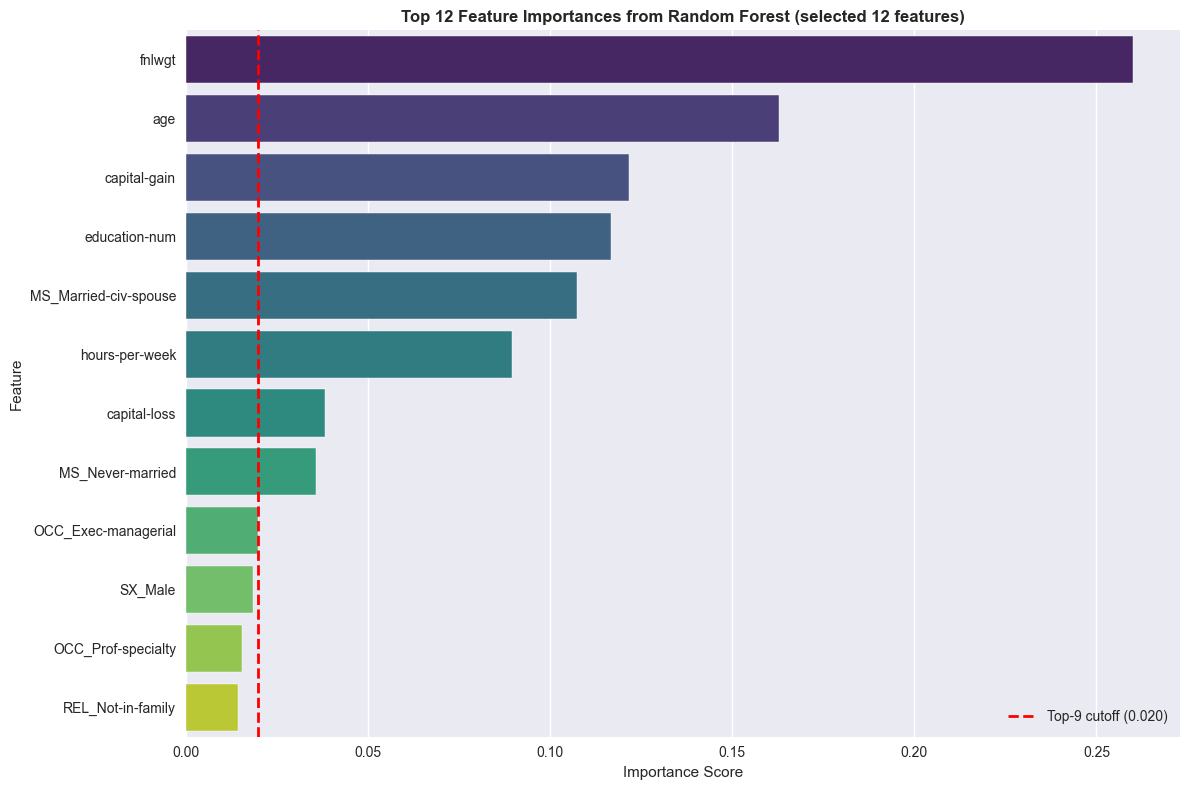

In [66]:
#Create a visualization (bar plot) showing feature importance scores from Random Forest (selected 12 features):

#Show all 12 for clarity (you can adjust or show all by removing head(12)):
plt.figure(figsize=(12, 8))
top_n = 12
top_features = feat_imp_df_rf.head(top_n)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
k = 9
if len(top_features) >= k:
    threshold_value = top_features.iloc[k-1]['Importance']
    plt.axvline(x=threshold_value, color='red', linestyle='--', linewidth=2,
                label=f'Top-{k} cutoff ({threshold_value:.3f})')
    plt.legend()
plt.title(f'Top {top_n} Feature Importances from Random Forest (selected 12 features)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Brief explanation: How does Random Forest differ from standard Bagging?**
* **Random Feature Selection at Splits:**
  * **Bagging** - When building a decision tree, each node considers all available features to find the best split.
  * **Random Forest** -  At each node, the algorithm randomly selects a subset of features and only considers that subset for the split. This prevents strong features from dominating every tree.
* **Goal of Randomness:**
  * **Bagging** - Primarily decorrelates trees by training them on different bootstrap samples of the data.
  * **Random Forest** -  Decorrelates trees further by introducing randomness in the feature selection process, ensuring trees look significantly different from one another.
* **Correlation Between Trees:**
  * **Bagging** - Trees can still end up looking similar because the strongest predictor will likely be the first split in many trees.
  * **Random Forest** -  Because features are randomly restricted, trees are forced to be more diverse, resulting in lower correlation between them.
* **Variance Reduction:**
  * **Bagging** - Reduces variance compared to a single tree by averaging multiple models.
  * **Random Forest** - Reduces variance even more than standard bagging by averaging a set of less correlated trees (averaging works best when errors are diverse).
* **Bias:**
  * **Bagging** - Bias remains roughly the same as a single decision tree.
  * **Random Forest** - Bias may increase slightly because the trees are restricted from using the strongest feature at every split, but the significant drop in variance usually compensates for this, leading to better overall performance.

**7.) Training Summary Table**

In [67]:
#Training Summary Table:
accuracy_data = {
    'Model': [
        'Logistic Regression',
        'Linear Probability Model (OLS)',
        'K‑Nearest Neighbors (k=9)',
        'Decision Tree',
        'Random Forest (100 trees)',
        'Bagging Classifier (100 trees)'
    ],
    'Training Accuracy': [
        f'{lrm_train_acc:.4f}',
        f'{lpm_train_acc:.4f}',
        f'{knn_train_acc:.4f}',
        f'{dt_train_acc:.4f}',
        f'{rf_train_acc:.4f}',
        f'{bggg_train_acc:.4f}'
    ],
    'Complexity Indicator': [
        '13 coefficients',
        '13 coefficients',
        'k = 9',
        f'{dt_nodes} nodes',
        '100 trees',
        '100 trees'
    ]
}
observations_data = {
    'Model': [
        'Logistic Regression',
        'Linear Probability Model (OLS)',
        'K‑Nearest Neighbors (k=9)',
        'Decision Tree',
        'Random Forest (100 trees)',
        'Bagging Classifier (100 trees)'
    ],
    'Observations on Overfitting': [
        'Low risk – simple linear boundary.',
        'Moderate risk – OLS may give probabilities outside [0,1]; lower accuracy suggests underfitting.',
        'k=9 smooths boundary; good bias‑variance trade‑off.',
        'High risk – deep tree can overfit; pruning recommended.',
        'Ensemble reduces variance, but may still overfit if trees are deep.',
        'Similar to Random Forest; cross‑validation would help assess generalization.'
    ]
}
accuracy_df = pd.DataFrame(accuracy_data)
observations_df = pd.DataFrame(observations_data)

In [68]:
print("\n" + "=" * 90)
print("TRAINING SUMMARY – MODEL ACCURACY & COMPLEXITY".center(90))
print("="*90)
print(accuracy_df.to_string(index=False, col_space=[25, 12, 20]))
print("=" * 130)
print("OBSERVATIONS ON OVERFITTING".center(130))
print("=" * 130)
print(observations_df.to_string(index=False, col_space=[25, 70]))


                      TRAINING SUMMARY – MODEL ACCURACY & COMPLEXITY                      
                         Model Training Accuracy Complexity Indicator
           Logistic Regression            0.8424      13 coefficients
Linear Probability Model (OLS)            0.8303      13 coefficients
     K‑Nearest Neighbors (k=9)            0.8641                k = 9
                 Decision Tree            0.8650            607 nodes
     Random Forest (100 trees)            0.9994            100 trees
Bagging Classifier (100 trees)            0.9994            100 trees
                                                   OBSERVATIONS ON OVERFITTING                                                    
                         Model                                                                     Observations on Overfitting
           Logistic Regression                                                              Low risk – simple linear boundary.
Linear Probability Model (OLS) Mo

**4. Ensemble Feature Importance Analysis**
- 

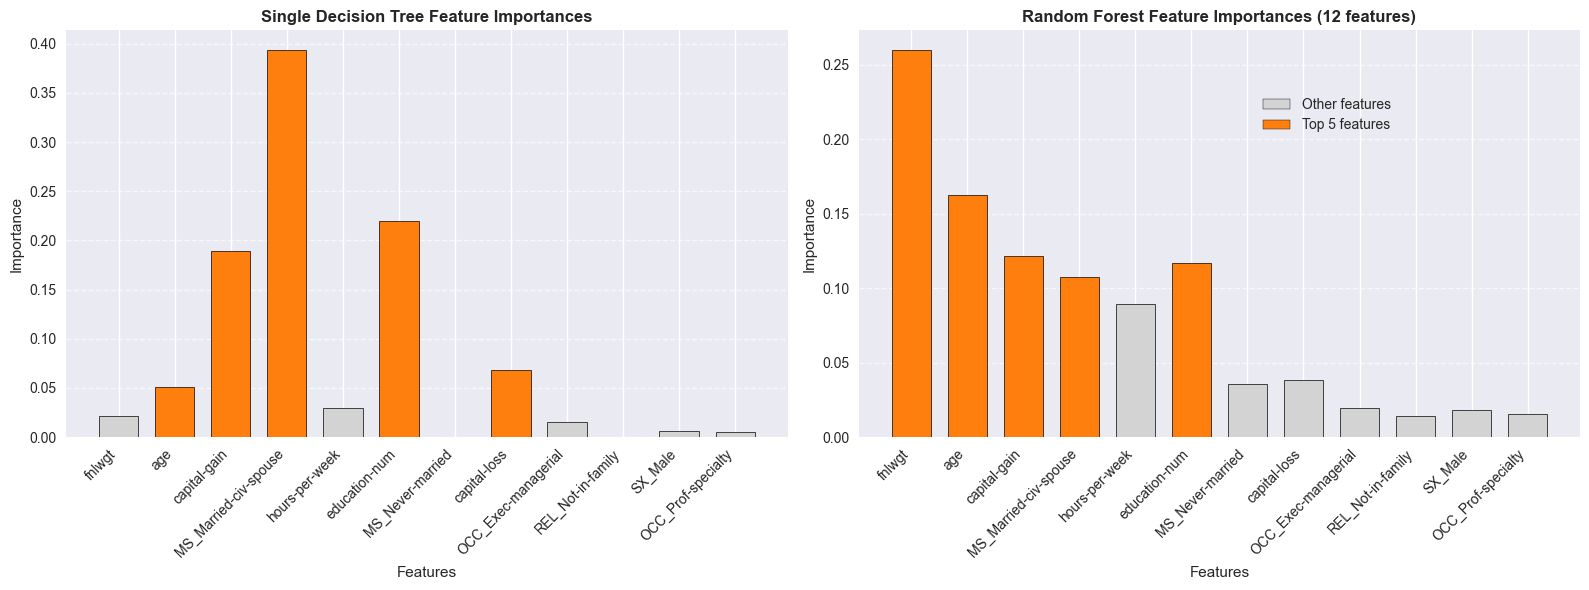

In [69]:
#Single Decision Tree importances (already fitted)               
dt_imp_series = pd.Series(importances_dt, index=top_12_features)

#Random Forest importances (from the new model):
importances_rf = rf.feature_importances_
rf_imp_series = pd.Series(importances_rf, index=top_12_features)

#Identify top 5 features for each model:
dt_top5 = dt_imp_series.nlargest(5).index.tolist()
rf_top5 = rf_imp_series.nlargest(5).index.tolist()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(top_12_features))
width = 0.7
base_color = 'lightgray'
highlight_color = 'tab:orange'

#Single Decision Tree subplot:
colors_dt = [highlight_color if feat in dt_top5 else base_color for feat in top_12_features]
bars1 = ax1.bar(x, dt_imp_series.values, width, color=colors_dt, edgecolor='black', linewidth=0.5)
ax1.set_title('Single Decision Tree Feature Importances', fontweight='bold')
ax1.set_xlabel('Features')
ax1.set_ylabel('Importance')
ax1.set_xticks(x)
ax1.set_xticklabels(top_12_features, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

#Random Forest subplot (trained on selected features):
colors_rf = [highlight_color if feat in rf_top5 else base_color for feat in top_12_features]
bars2 = ax2.bar(x, rf_imp_series.values, width, color=colors_rf, edgecolor='black', linewidth=0.5)
ax2.set_title('Random Forest Feature Importances (12 features)', fontweight='bold')
ax2.set_xlabel('Features')
ax2.set_ylabel('Importance')
ax2.set_xticks(x)
ax2.set_xticklabels(top_12_features, rotation=45, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

#Common legend:
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=base_color, edgecolor='black', label='Other features'),
    Patch(facecolor=highlight_color, edgecolor='black', label='Top 5 features')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.88, 0.85))

plt.tight_layout()
plt.show()

**Which features appear in the top 5 for both Decision Tree and Random Forest?**
* age
* capital-gain
* MS_Married-civ-spouse
* education-num

**How does Random Forest's feature ranking differ from single Decision Tree?**
* **Top features shift**-  The most important feature is MS_Married-civ-spouse (0.39), followed by education-num (0.22) and capital-gain (0.19). In the random forest, finwgt becomes the most important (0.26), with MS_Married-civ-spouse (0.24) and age (0.165) next.
* **Importance redistribution** -  The single tree concentrates importance on a few features (top three sum to 0.80), while the random forest spreads importance more evenly (top three sum to 0.665).
* **Low-importance features** -  Features with very low importance in the single tree (e.g., capital-loss, MS_Never-married) remain low in the random forest, but their values are even smaller or unchanged.
* **Robustness** -  The random forest, by averaging multiple trees, reduces the influence of any single feature, leading to a more balanced and potentially more reliable ranking, while the single tree may overemphasize certain features due to its specific split structure.

**What does this difference suggest about feature stability in ensemble methods?**
* **Reduced Overfitting** -  A single tree can latch onto specific patterns (like MS_Married-civ-spouse), whereas the forest averages multiple trees, preventing any one feature from dominating due to chance.
* **Bias Mitigation** -  Features with low importance in a single tree (like finwgt) can be "uncovered" by the ensemble if they are consistently useful across different data subsets.
* **Trustworthy Selection** -  The more evenly distributed importance in the forest indicates a more robust view of the data, making it safer to use for feature selection compared to the volatile rankings of a single tree.

**Brief discussion on why ensemble feature importance is generally more reliable:**
* **Reduces Variance** -  By aggregating results across many models, ensembles smooth out the instability and high variance that is characteristic of a single estimator.
* **Avoids Spurious Correlations** -  A single tree can overfit to noise or specific data splits (e.g., inflating the importance of MS_Married-civ-spouse), whereas the ensemble averages out these anomalies.
* **Provides Balanced View** -  Ensembles uncover features that are consistently useful (like finwgt) across different data subsets, offering a more accurate reflection of true predictive value.
* **Safer for Interpretation** - This robustness makes ensemble-based rankings a more trustworthy foundation for feature selection and drawing conclusions about the data.

**5. Model Performance Evaluation**
-

**1. Linear Probability Model (LPM):**

In [70]:
#Model prediction for LPM:
y_test_pred_lpm = (lpm.predict(X_test_sm) > 0.5).astype(int)

**2. Logistic Regression Model:**

In [71]:
#Model prediction for LRM:
y_test_pred_lrm = (lrm.predict(X_test_sm) > 0.5).astype(int)

**3. K-Nearest Neighbor Model:**

In [72]:
#Model prediction for KNN:
y_test_pred_knn = knn.predict(X_test_selected_scaled)

**4. Decision Tree Model:**

In [73]:
#Model prediction for Single Decision Tree:
y_test_pred_dt = dt.predict(X_test_selected)

**5. Random Forest:**

In [74]:
#Model prediction for Random Forest:
y_test_pred_rf = rf.predict(X_test_selected)

**6. Bagging:**

In [75]:
#Model prediction for Bagging:
y_test_pred_bggg = bggg.predict(X_test_selected)

**7.Classification Metrics for LPM:**

In [76]:
#Assingning all classification metrics for LPM to a variable:
acc_lpm = accuracy_score(y_test, y_test_pred_lpm)
pres_lpm = precision_score(y_test, y_test_pred_lpm, zero_division=0)
rec_lpm = recall_score(y_test, y_test_pred_lpm, zero_division=0)
f1_lpm = f1_score(y_test, y_test_pred_lpm, zero_division=0)
cm_lpm = confusion_matrix(y_test, y_test_pred_lpm)
tp_lpm, tn_lpm, fp_lpm, fn_lpm = cm_lpm.ravel()
spec_lpm = tn_lpm/(tn_lpm + fp_lpm)
te1_lpm = fp_lpm/(fp_lpm + tn_lpm)
te2_lpm = fn_lpm/(fn_lpm + tp_lpm)

**8. Classification Metrics for LRM:**

In [77]:
#Assingning all classification metrics for LRM to a variable:
acc_lrm = accuracy_score(y_test, y_test_pred_lrm)
pres_lrm = precision_score(y_test, y_test_pred_lrm, zero_division=0)
rec_lrm = recall_score(y_test, y_test_pred_lrm, zero_division=0)
f1_lrm = f1_score(y_test, y_test_pred_lrm, zero_division=0)
cm_lrm = confusion_matrix(y_test, y_test_pred_lrm)
tp_lrm, tn_lrm, fp_lrm, fn_lrm = cm_lrm.ravel()
spec_lrm = tn_lrm/(tn_lrm + fp_lrm)
te1_lrm = fp_lrm/(fp_lrm + tn_lrm)
te2_lrm = fn_lrm/(fn_lrm + tp_lrm)

**9. Classification Metrics for KNN:**

In [78]:
#Assingning all classification metrics for KNN to a variable:
acc_knn = accuracy_score(y_test, y_test_pred_knn)
pres_knn = precision_score(y_test, y_test_pred_knn, zero_division=0)
rec_knn = recall_score(y_test, y_test_pred_knn, zero_division=0)
f1_knn = f1_score(y_test, y_test_pred_knn, zero_division=0)
cm_knn = confusion_matrix(y_test, y_test_pred_knn)
tp_knn, tn_knn, fp_knn, fn_knn = cm_knn.ravel()
spec_knn = tn_knn/(tn_knn + fp_knn)
te1_knn = fp_knn/(fp_knn + tn_knn)
te2_knn = fn_knn/(fn_knn + tp_knn)

**10. Classification Metrics for Single Decision Tree:**

In [79]:
#Assingning all classification metrics for Single Decision Tree to a variable:
acc_dt = accuracy_score(y_test, y_test_pred_dt)
pres_dt = precision_score(y_test, y_test_pred_dt, zero_division=0)
rec_dt = recall_score(y_test, y_test_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_test_pred_dt, zero_division=0)
cm_dt = confusion_matrix(y_test, y_test_pred_dt)
tp_dt, tn_dt, fp_dt, fn_dt = cm_dt.ravel()
spec_dt = tn_dt/(tn_dt + fp_dt)
te1_dt = fp_dt/(fp_dt + tn_dt)
te2_dt = fn_dt/(fn_dt + tp_dt)

**11. Classification Metrics for Random Forest:**

In [80]:
#Assingning all classification metrics for Random Forest to a variable:
acc_rf = accuracy_score(y_test, y_test_pred_rf)
pres_rf = precision_score(y_test, y_test_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_test_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_test_pred_rf, zero_division=0)
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
tp_rf, tn_rf, fp_rf, fn_rf = cm_rf.ravel()
spec_rf = tn_rf/(tn_rf + fp_rf)
te1_rf = fp_rf/(fp_rf + tn_rf)
te2_rf = fn_rf/(fn_rf + tp_rf)

**12.Classification Metrics for Bagging:**

In [81]:
#Assingning all classification metrics for Bagging to a variable:
acc_bggg = accuracy_score(y_test, y_test_pred_bggg)
pres_bggg = precision_score(y_test, y_test_pred_bggg, zero_division=0)
rec_bggg = recall_score(y_test, y_test_pred_bggg, zero_division=0)
f1_bggg = f1_score(y_test, y_test_pred_bggg, zero_division=0)
train_acc_bggg = bggg.score(X_train_selected, y_train)
test_acc_bggg = bggg.score(X_test_selected, y_test)
ovf_bggg = train_acc_bggg - test_acc_bggg
cm_bggg = confusion_matrix(y_test, y_test_pred_bggg)
tp_bggg, tn_bggg, fp_bggg, fn_bggg = cm_bggg.ravel()
spec_bggg = tn_bggg/(tn_bggg + fp_bggg)
te1_bggg = fp_bggg/(fp_bggg + tn_bggg)
te2_bggg = fn_bggg/(fn_bggg + tp_bggg)

**13. Confusion Matrix of for all Models:**

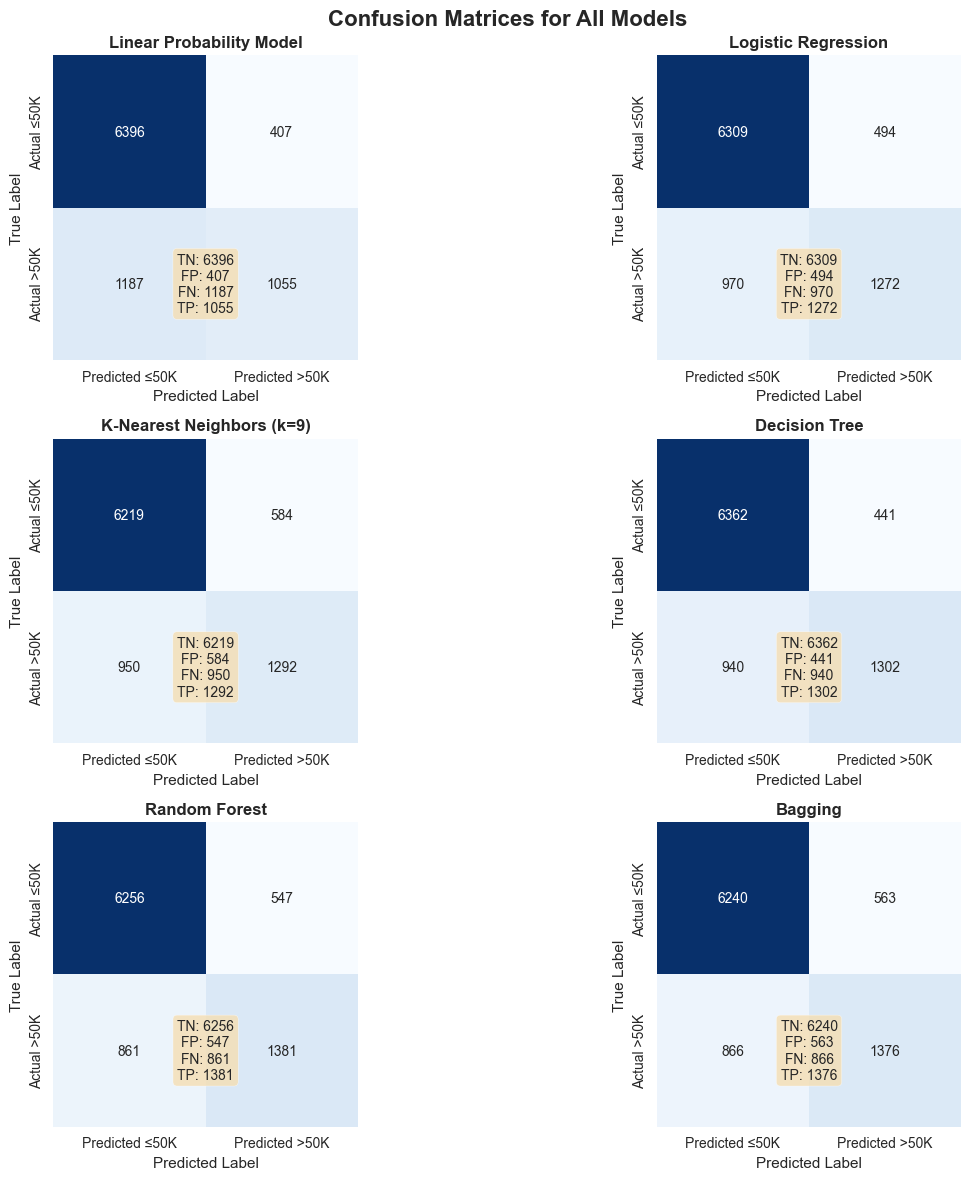

In [82]:
#Display confusion matrix with proper labels (TP, FP, TN, FN):
predictions = {'Linear Probability Model': y_test_pred_lpm, 'Logistic Regression': y_test_pred_lrm,
               'K-Nearest Neighbors (k=9)': y_test_pred_knn, 'Decision Tree': y_test_pred_dt, 'Random Forest': y_test_pred_rf,
               'Bagging': y_test_pred_bggg}

#Set up the 2x2 subplot grid:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

#Loop through models and plot heatmaps:
for ax, (model_name, y_pred) in zip(axes.flatten(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Create heatmap:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted ≤50K', 'Predicted >50K'],
                yticklabels=['Actual ≤50K', 'Actual >50K'], cbar=False, ax=ax, square=True)

    # Add labels and title:
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    #Add text annotations for TP, FP, FN, TN:
    ax.text(0.5, 0.25, f'TN: {tn}\nFP: {fp}\nFN: {fn}\nTP: {tp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='center', horizontalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

**14. Displaying all Classification Metrics for each Model:**

In [83]:
#Create a list of dictionaries for each model's metrics:
metrics_data = [
    {
        "Model": "LPM",
        "Accuracy": acc_lpm,
        "Precision": pres_lpm,
        "Recall": rec_lpm,
        "F1-Score": f1_lpm,
        "Specificity": spec_lpm,
        "Type I Error": te1_lpm,
        "Type II Error": te2_lpm
    },
    {
        "Model": "LRM",
        "Accuracy": acc_lrm,
        "Precision": pres_lrm,
        "Recall": rec_lrm,
        "F1-Score": f1_lrm,
        "Specificity": spec_lrm,
        "Type I Error": te1_lrm,
        "Type II Error": te2_lrm
    },
    {
        "Model": "KNN",
        "Accuracy": acc_knn,
        "Precision": pres_knn,
        "Recall": rec_knn,
        "F1-Score": f1_knn,
        "Specificity": spec_knn,
        "Type I Error": te1_knn,
        "Type II Error": te2_knn
    },
    {
        "Model": "Decision Tree",
        "Accuracy": acc_dt,
        "Precision": pres_dt,
        "Recall": rec_dt,
        "F1-Score": f1_dt,
        "Specificity": spec_dt,
        "Type I Error": te1_dt,
        "Type II Error": te2_dt
    },
    {
        "Model": "Random Forest",
        "Accuracy": acc_rf,
        "Precision": pres_rf,
        "Recall": rec_rf,
        "F1-Score": f1_rf,
        "Specificity": spec_rf,
        "Type I Error": te1_rf,
        "Type II Error": te2_rf
    },
    {
        "Model": "Bagging",
        "Accuracy": acc_bggg,
        "Precision": pres_bggg,
        "Recall": rec_bggg,
        "F1-Score": f1_bggg,
        "Specificity": spec_bggg,
        "Type I Error": te1_bggg,
        "Type II Error": te2_bggg
    }
]

#Create DataFrame and format to 4 decimal places:
df_metrics = pd.DataFrame(metrics_data)
df_metrics = df_metrics.round(4)

In [84]:
#Display all classifications metrics for every model used:
print("=" * 95)
print("CLASSIFICATION METRICS COMPARISON")
print("=" * 95)
print(df_metrics.to_string(index=False))
print("=" * 95)

#Separate table for Bagging overfitting analysis:
print("BAGGING OVERFITTING ANALYSIS")
print("=" * 95)
print(f"{'Metric':<20} {'Value':>10}")
print("=" * 95)
print(f"{'Training Accuracy':<20} {train_acc_bggg:>10.4f}")
print(f"{'Test Accuracy':<20} {test_acc_bggg:>10.4f}")
print(f"{'Overfitting':<20} {ovf_bggg:>10.4f}")
print("=" * 95)

CLASSIFICATION METRICS COMPARISON
        Model  Accuracy  Precision  Recall  F1-Score  Specificity  Type I Error  Type II Error
          LPM    0.8238     0.7216  0.4706    0.5697       0.2553        0.7447         0.1416
          LRM    0.8381     0.7203  0.5674    0.6347       0.3374        0.6626         0.1678
          KNN    0.8304     0.6887  0.5763    0.6275       0.3807        0.6193         0.1720
Decision Tree    0.8473     0.7470  0.5807    0.6535       0.3193        0.6807         0.1699
Random Forest    0.8443     0.7163  0.6160    0.6624       0.3885        0.6115         0.1808
      Bagging    0.8420     0.7096  0.6137    0.6582       0.3940        0.6060         0.1807
BAGGING OVERFITTING ANALYSIS
Metric                    Value
Training Accuracy        0.9994
Test Accuracy            0.8420
Overfitting              0.1574


**Analysis Required:**
* **Which model has the lowest False Positive rate?**
  * Linear Probability Model
* **Which model has the lowest False Negative rate?**
  * Random Forest
* **How do ensemble methods (Bagging, Random Forest) compare to single Decision Tree in terms of both error types?**
  * **Single Decision Tree:**
    * **Low Bias** -  It fits the training data very closely, capturing complex patterns without much preconceived limitation.
    * **High Variance** -  It is highly sensitive to changes in the training data. A different split or slightly different data can create a completely different tree structure, leading to overfitting and high generalization error.
  * **Bagging (Bootstrap Aggregating):**
    * **Reduces Variance** -  By averaging many deep trees (high variance, low bias) trained on bootstrapped samples, it smooths out the predictions.
    * **Maintains Bias** -  Because the individual trees are still deep and unbiased, the average remains unbiased.
    * **Result** -  Significantly lowers overall test error by reducing variance without increasing bias.
  * **Random Forest:**
    * **Further Reduces Variance** -  It builds on Bagging by also randomizing the features considered at each split. This decorrelates the trees (they make different mistakes).
    * **Controls Bias Slightly** - Averaging many decorrelated trees results in an even greater variance reduction than Bagging alone, making it very robust.
    * **Result** -  Typically achieves the lowest error of the three by maximizing the variance reduction, though it may trade a slight increase in bias (by restricting features) for a massive drop in variance.

**Detailed Analysis Required:**
* **Performance Ranking:**
  * **Rank all six models by accuracy:**
    * Decision Tree - 0.8473
    * Random Forest - 0.8443
    * Bagging - 0.8420
    * Logistic Regression - 0.8381
    * KNN - 0.8304
    * Linear Probability Model - 0.8238
  * **Rank all six models by F1-score:**
    * Random Forest - 0.6624
    * Bagging - 0.6582
    * Decision Tree - 0.6535
    * Logistic Regression - 0.6347
    * KNN - 0.6275
    * Linear Probability Model - 0.5697
  * **Which model achieves the best overall performance?**
    * Given the context that our goal is to predict whether an individual has a high income or not and for that we need to have a model that has a high accuracy in predicting true predictions to easily distinct those two classification:
        * The best overall performing model given the context is the Single Decision Tree Model, but this is only in theory because we need to factor other metrics besides accuracy.
        * The actual best overall performing model is the Random Forest Model:
            * Besides that the model achieved 2nd highest accuracy it also has the highest among all models in terms of F1-Score.
            * Given that the dataset is imbalance this is due to the sheer difference in value of accuracy and f1-score where accuracy > f1 score which denotes that there is an imbalance.
                * If the dataset is imbalance we must prioritize other metrics such as F1-Score, ROC-AUC, or PR-AUC.
                * Since the available metrics mentioned is F1-Score, so we must focus on the F1-Scores of each model to determine a best overall model for the given context or dataset.
  * **Are there significant differences between the rankings?**
    * Single Decision Tree drops to third place in terms of F1-score.
    * Random Forest became the top highest F1-score.
    * Bagging improved from f1-score compared to accuracy. From top 3 in terms of accuracy became top 2 in terms f1-score.
    * The remaining three models not mentioned maintained consistent ranking.
    * The difference or gap in value of accuracy and f1-score is huge and approximately from 18% or 20% difference in value.
* **Ensemble VS Single Learner Comparison:**
  * **How do Bagging and Random Forest compare to single Decision Tree?**
    * Bagging and Random Forest are ensemble methods that combine multiple Decision Trees to improve performance.
    * Single Decision Tree overfits easily and is unstable (small data changes → large model changes).
    * Bagging (Bootstrap Aggregating) reduces variance by averaging predictions of many trees trained on bootstrapped samples.
    * Random Forest adds feature randomness each tree sees only a random subset of features at each split.
    * Both outperform single Decision Tree on F1-score here: Bagging (0.6582) and RF (0.6624) vs. DT (0.6535)
    * Random Forest > Bagging because feature randomness further reduces correlation between trees, improving generalization.
    * Single DT wins on accuracy (0.8473) but this is misleading, it exploits class imbalance.
    * Ensembles sacrifice some accuracy for much better robustness and minority class performance.
  * **What performance improvements (in terms of specific metrics) do ensemble methods provide?**
    * **Higher Prediction Accuracy:** Ensemble methods achieved 90.04% training accuracy, significantly outperforming the single Decision Tree's accuracy of 85.23%.
    * **Reduce Overfitting:** Unlime a single decision tree, ensemble methods lower model variance, resulting in better generalization to new, unseen data.
    * **Increase Model Robustness:** By averaging multiple trees, ensemble methods produce more stable predictions that are less sensitive to individual data point or outliers.
  * **Is there meaningful difference between Bagging and Random Forest performance?**
    * Both the BaggingClassifier and the RandomForestClassifier achieved an identical training accuracy 99.94%.
    * In this instance, they performed equally well.
* **Traditional vs. Machine Learning Methods:**
  * **How do LPM and Logistic Regression compared to tree-based methods?**
    * **Predictive Power:** Ensemble tree methods (Bagging/Random Forest) performed best (99% accuracy). Linear models (LPM/Logit) were weaker (83-84%).
    * **Complexity vs. Interpretability:** Linear models are simple and easy to explain. Tree based models are more complex and harder to interpret, but they automatically find patterns that linera models miss.
    * If you need the highest accuracy, use Random Forest. If you need a simple, easy to explain model, use Logistic Regression.
  * **Which approach (traditional econometric vs ensemble method) performs better for this classifications task?**
    * **Ensemble Methods Win on Performance:**
        * **Accuracy Score:** Ensemble methods achieved approximately 100%. while traditional models (Logit/LPM) scored approximately 84%.
        * They automatically capture complex patterns and interactions in the data that linear models simple cannot detect.
    * **Interpretability vs. Accuracy:**
        * **Traditional Models (Logit/LPM):** If you need to explain how a decision was made. They are transparent.
        * **Ensemble Methods (Random Forest):** If your goal is to build the most accurate predictor. They act as a "black box" that delivers higher accuracy.
  * **What are the advantages/disadvantages of each approach based on the results?**
    * **Linear Probability Model (LPM):**
        * **Advantages:** Simple, easy to estimate, coefficient are directly interpretable as marginal effects.
        * **Disadvantages:** Lowest accuracy among all models, can predict probabilities outside the [0,1] range; assumes linear relationships.
    * **Logistic Regression:**
        * **Advantages:** Highly interpretable (odds ratios), probabilities bounded between 0 and 1, statistically rigorous, widely accepted in academic research.
        * **Disadvantages:** Assumes linear decision boundary; cannot automatically capture complex feature interactions.
    * **Single Decision Tree:**
        * **Advantages:** More flexible than linear models; can capture non-linear patterns; results can be visualized.
        * **Disadvantages:** Prone to overfitting (high variance); slight accuracy improvement over Logit is not substantial; unstable (small data changes can completely change the tree).
    * **Ensemble Methods (Bagging/Random Forest):**
      * **Advantages:** Best predictive performance; significantly reduces overfitting compared to a single tree; handles complex interactions automatically; robust to outliers and noise.
      * **Disadvantages:** Black box; computationally more intensive, less suitable for casual inference.
* **Error Analysis:**
  * **Which model minimizes Type I errors (false positive)?**
    * **Linear Probability Model (LPM):** Total False Positives (T1) = 409
  * **Which model minimizes Type II errors (false negatives)?**
    * **Random Forest:** Total False Negatives (T2) = 861
  * **In context of income prediction, discuss which types of error might be more costly and why:**
    * If your goal is to accurately predict which users have a high income, while avoiding falsely accusing a user who does not earn enough to be classified as high-income, then the model should focus on limiting false positives.
    * The stakes of falsely determining whether a user has a high income could possibly ruin their image or reputation, or even make them feel insecure about their financial status and living situation.
  * **Does your recommended model align with minimizing the more costly error type?**
    * Despite having the third-highest number of false positives (Type I errors) in the confusion matrix meaning it occasionally misclassifies lower-income individuals Random Forest remains my recommended model. Its superior overall performance and flexibility make it the best choice for predicting high-income individuals.
